# Data Loading and Preparation

## Basic Imports

In [216]:
# Data handling
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Pathing
from pathlib import Path

# Modelling
import joblib

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Make plots look nicer
sns.set_theme(style="whitegrid")
%matplotlib inline

## Load Processed Feature Dataset for Evaluation

In [197]:
split_path = Path("../data/splits")
X_test = pd.read_csv(split_path / "X_test.csv")
y_test = pd.read_csv(split_path / "y_test.csv").squeeze()
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (17005, 21)
y_test shape: (17005,)


### Cast to Categorical for Native Handling

In [198]:
categorical_cols = ["state", "service", "proto", "dsport"]
for col in categorical_cols:
    X_test[col] = X_test[col].astype("category")

## Load Model From Disk

In [199]:
model_path = Path("../models/xgboost_classifier_model.pkl")
model = joblib.load(model_path)
print(f"Model retrieved from {model_path}")

Model retrieved from ../models/xgboost_classifier_model.pkl


# Model Evaluation

## XGBoost Classifier Model

### Generate Predictions and Probabilities

In [200]:
attack_prob = model.predict_proba(X_test)[:, 1]
pred_labels = model.predict(X_test)

### Evaluate and Visualise Predictions

#### Quick Stats

In [201]:
num_attacks = pred_labels.sum()
print(f"Number of predicted attacks: {num_attacks}")

Number of predicted attacks: 12685


#### Classification Report

In [202]:
print(classification_report(y_test, pred_labels))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      4181
           1       0.98      0.97      0.98     12824

    accuracy                           0.96     17005
   macro avg       0.95      0.96      0.95     17005
weighted avg       0.96      0.96      0.96     17005



#### Confusion Matrix

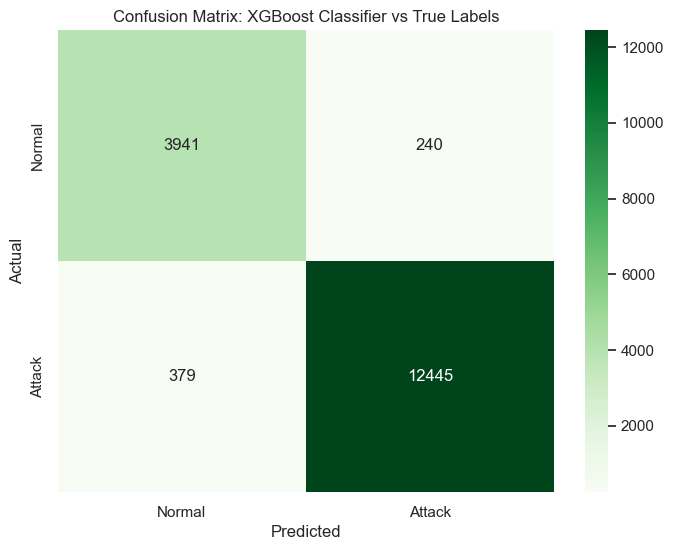

In [204]:
cm = confusion_matrix(y_test, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: XGBoost Classifier vs True Labels")
plt.show()

#### Probability Distributions

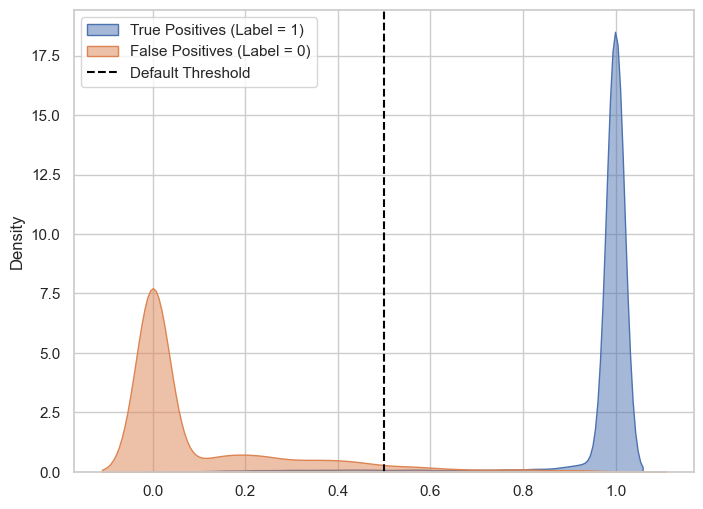

In [207]:
tp_probs = attack_prob[y_test == 1]
fp_probs = attack_prob[y_test == 0]
plt.figure(figsize=(8, 6))
sns.kdeplot(tp_probs, label="True Positives (Label = 1)", fill=True, alpha=0.5)
sns.kdeplot(fp_probs, label="False Positives (Label = 0)", fill=True, alpha=0.5)
plt.axvline(0.5, color="black", linestyle="--", label="Default Threshold")
plt.legend()
plt.show()

#### Experiment with Threshold Tuning

In [208]:
threshold = 0.1
custom_preds = (attack_prob >= threshold).astype(int)
print(classification_report(y_test, custom_preds))

              precision    recall  f1-score   support

           0       1.00      0.72      0.84      4181
           1       0.92      1.00      0.96     12824

    accuracy                           0.93     17005
   macro avg       0.96      0.86      0.90     17005
weighted avg       0.94      0.93      0.93     17005



Varying the decision threshold between 0.5 and 0.8 did not materially improve f1-scores or class balances (only shifting a small number of borderline cases). This suggests the model produces well-separated probabilities and tuning provides limited gains.

### Inspect Model Feature Importances

#### Extract Importances

In [209]:
features = model.feature_names_in_.tolist()
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feat_imp)

sttl_x_ct_state_ttl    0.443967
sttl_x_ttl_diff        0.184176
ct_state_ttl           0.135997
dsport                 0.071582
proto                  0.043335
service                0.040993
state                  0.018141
sttl                   0.016694
dloss                  0.006734
ttl_diff               0.006302
sloss                  0.005623
ct_dst_src_ltm         0.005185
mean_pkt_sz_ratio      0.004622
ttl_diff_bin           0.003518
res_bdy_len            0.002549
trans_depth            0.002186
anomaly_score          0.002160
Dintpkt                0.002039
Shourofday             0.001468
Sintpkt                0.001391
dur                    0.001339
dtype: float32


First-pass model was heavily dominated by `sttl` (66% importance). Remaining features provided minor contributions. Strong reliance on a single feature may indicate potential sensitivity to feature drift.

Removing `sttl` during ablation testing had minimal impact on model performance, suggesting that the remaining features alone captured strong signal and effectively separated true positives from false positives. Additionally, feature importances became more balanced, with no single feature dominating.

#### Plot Importances

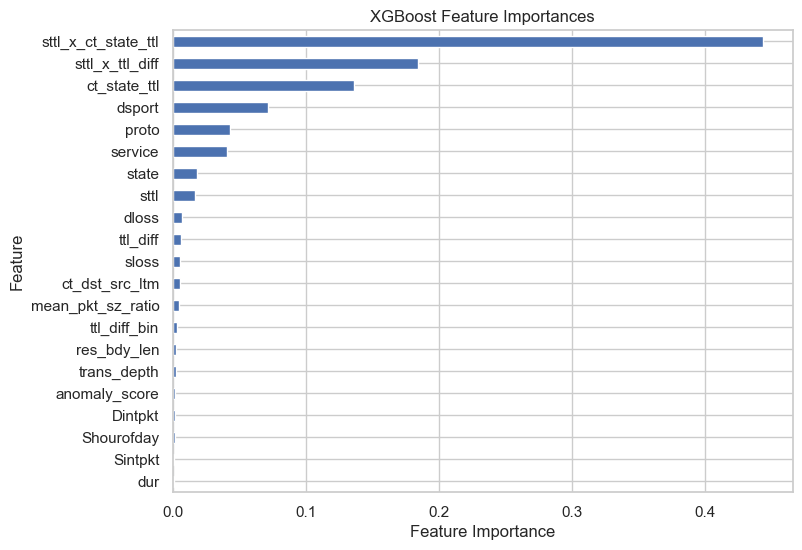

In [210]:
feat_imp.sort_values(ascending=True).plot(kind="barh", figsize=(8, 6))
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importances")
plt.show()

### Mistake Analysis

#### Group Predictions

In [213]:
# Define groups
fp_correct = X_test[(y_test == 0) & (pred_labels == 0)]
fp_misclassified = X_test[(y_test == 0) & (pred_labels == 1)]
tp_correct = X_test[(y_test == 1) & (pred_labels == 1)]
tp_misclassified = X_test[(y_test == 1) & (pred_labels == 0)]

#### Compare Distributions

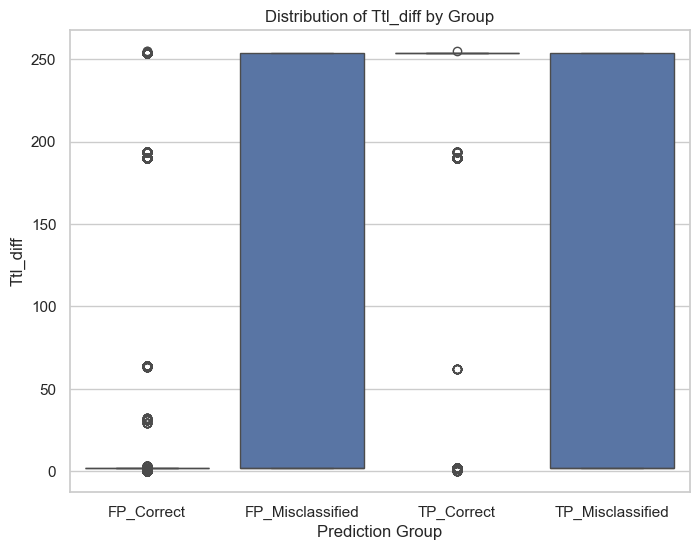

In [215]:
# Combine into one DataFrame
df_plot = pd.concat([
    fp_correct.assign(Group="FP_Correct"),
    fp_misclassified.assign(Group="FP_Misclassified"),
    tp_correct.assign(Group="TP_Correct"),
    tp_misclassified.assign(Group="TP_Misclassified")
])
feature = "ttl_diff"
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_plot, x="Group", y=feature)
plt.xlabel("Prediction Group")
plt.ylabel(feature.capitalize())
plt.title(f"Distribution of {feature.capitalize()} by Group")
plt.show()